## Préparation

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv("data/orders.csv")
order_products = pd.read_csv("data/order_products.csv")
products = pd.read_csv("data/products.csv")
aisles = pd.read_csv("data/aisles.csv")
departments = pd.read_csv("data/departments.csv")

df = (
    order_products
    .merge(orders, on="order_id", how="left")
    .merge(products, on="product_id", how="left")
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)


## Nettoyage des données

In [111]:
#------------------------------------------------------   NETTOYAGE

#dropna ou filna

df = df.dropna(subset=["product_id"])
df["reordered"] = df["reordered"].fillna(0)
df = df.dropna(subset=["user_id"])

# colonnes à convertir en entier
cols_to_int = [
    "product_id", 
    "add_to_cart_order", 
    "reordered", 
    "user_id", 
    "order_number", 
    "order_dow", 
    "aisle_id", 
    "department_id",
    "eval_set"  
]

# convertir en entier  (int64 pour les nan)
df[cols_to_int] = df[cols_to_int].astype("Int64")

# Remplacements colonnes valeurs: 
df["order_number"], df["order_dow"] = df["order_dow"], df["order_number"]

df["order_number"], df["order_hour_of_day"] = df["order_hour_of_day"], df["order_number"]

#------------------------------------------------------------------------- NETTOYAGE

## Nombre total de commandes

In [112]:
total_orders = df["order_id"].nunique()
print("Nombre total de commandes :", total_orders)

Nombre total de commandes : 1357511


## Nombre total de produits

In [113]:
total_products = df["product_id"].nunique()
print("Nombre total de produits :", total_products)

Nombre total de produits : 49067


## Produits par commande

In [114]:
product_par_basket = df.groupby("order_id")["product_id"].count()

## Panier moyen

In [115]:
average_basket = product_par_basket.mean()
print("Panier moyen :", round(average_basket, 1))

Panier moyen : 10.1


## Top des produits les plus vendus

In [116]:
lemost = df.groupby(["product_id", "product_name"]).size().sort_values(ascending=False)
print(lemost.head())

product_id  product_name          
24852       Banana                    199647
13176       Bag of Organic Bananas    160613
21137       Organic Strawberries      111972
21903       Organic Baby Spinach      101911
47209       Organic Hass Avocado       90368
dtype: int64


# Départements les plus populaires

In [117]:
dept_popularity = df.groupby(["department_id", "department"]).size().reset_index(name="nb_ventes").sort_values(by="nb_ventes", ascending=False)
dept_popularity.head()

,department_id,department,nb_ventes
3,4,produce,4005228
15,16,dairy eggs,2286342
18,19,snacks,1216498
6,7,beverages,1135998
0,1,frozen,943878


## Commandes par jours

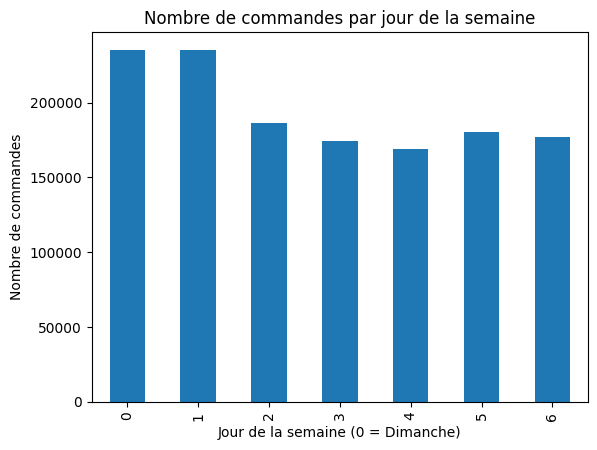

In [118]:
# compter le nombre de commandes par jour
orders_per_day = df.groupby("order_dow")["order_id"].nunique()

# graphique
orders_per_day.plot(kind="bar")

plt.title("Nombre de commandes par jour de la semaine")
plt.xlabel("Jour de la semaine (0 = Dimanche)")
plt.ylabel("Nombre de commandes")

plt.show()